In [1]:
"""
Logistic Regression (GLM - Binomial) Analysis
==============================================
Research Question:
    To what extent do subjective confidence, frame type (Before Boundary BB vs.
    Event-Middle EM), and video editing style (NB vs. AB) predict the probability
    of correct frame recognition?

Model:
    DV  : resp.corr        (binary: 1 = correct, 0 = incorrect)
    IVs : Condition        (NB vs. AB)
          Target_Type      (BB vs. EM, extracted from target_img filename)
          Confidence       (conf_radio.response, 1-5 Likert scale)
    Interaction: Condition × Confidence  (tests boundary-advantage / confidence link)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# statsmodels for GLM
import statsmodels.formula.api as smf
import statsmodels.api as sm

# sklearn for ROC / AUC
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# scipy for odds-ratio CIs from log-OR
from scipy import stats

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEANED_DIR = Path("../data/individuals_cleaned")
OUTPUT_DIR  = Path("../exploration_output/logistic_regression")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_list_value(val):
    """Parse values stored as string lists like '[9.14]'."""
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    try:
        val_str = str(val).strip()
        if val_str.startswith('[') and val_str.endswith(']'):
            inner = val_str[1:-1].strip()
            if inner:
                return float(inner)
        return float(val_str)
    except Exception:
        return np.nan


def extract_target_type(img_path: str) -> str:
    """
    Extract target type from filename.
    Filenames look like: frames\\Vid33_BB_T.png  or  frames/Vid9_EM_T.png
    Returns 'BB' or 'EM', else NaN.
    """
    if pd.isna(img_path):
        return np.nan
    img_path = str(img_path).replace("\\", "/")
    fname = img_path.split("/")[-1]        # e.g. "Vid33_BB_T.png"
    parts = fname.split("_")               # ['Vid33', 'BB', 'T.png']
    for part in parts:
        if part in ("BB", "EM"):
            return part
    return np.nan


# ── Data Loading ──────────────────────────────────────────────────────────────
def build_trial_dataframe() -> pd.DataFrame:
    """
    Walk every cleaned participant CSV, extract trial-level rows, and
    return one combined long-format DataFrame ready for modelling.
    """
    csv_files = sorted(CLEANED_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {CLEANED_DIR}")

    print(f"Loading {len(csv_files)} participant files …")
    records = []

    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file, low_memory=False)

            # ── participant meta ──────────────────────────────────────────────
            condition     = ('AB' if '_AB_' in csv_file.name else
                             'NB' if '_NB_' in csv_file.name else 'Unknown')
            participant_id = csv_file.stem.split('_')[0]   # e.g. 'sub14'

            # ── keep only recognition-task trial rows ─────────────────────────
            trials = df[df['resp.corr'].notna()].copy()
            if trials.empty:
                continue

            # ── parse columns ─────────────────────────────────────────────────
            trials['resp.corr']         = pd.to_numeric(trials['resp.corr'],         errors='coerce')
            trials['conf_radio.response'] = trials['conf_radio.response'].apply(parse_list_value)
            trials['resp.rt']           = trials['resp.rt'].apply(parse_list_value)

            # ── derive Target_Type ────────────────────────────────────────────
            trials['Target_Type'] = trials['target_img'].apply(extract_target_type)

            # ── assemble record per trial ─────────────────────────────────────
            for _, row in trials.iterrows():
                records.append({
                    'Participant'  : participant_id,
                    'Condition'    : condition,
                    'Target_Type'  : row['Target_Type'],
                    'Confidence'   : row['conf_radio.response'],
                    'Resp_Corr'    : row['resp.corr'],
                    'RT'           : row['resp.rt'],
                    'movie_id'     : row.get('movie_id', np.nan),
                    'target_img'   : row.get('target_img', np.nan),
                })

        except Exception as e:
            print(f"  ⚠  Error reading {csv_file.name}: {e}")

    long_df = pd.DataFrame(records)
    return long_df


# ── Pre-processing ────────────────────────────────────────────────────────────
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and encode the long-format trial DataFrame.
    """
    print(f"\nTotal trials before cleaning : {len(df)}")

    # Drop rows missing key variables
    df = df.dropna(subset=['Resp_Corr', 'Confidence', 'Target_Type', 'Condition'])
    print(f"Total trials after dropna    : {len(df)}")

    # Ensure types
    df['Resp_Corr']  = df['Resp_Corr'].astype(int)
    df['Confidence'] = df['Confidence'].astype(float)

    # ── Dummy / treatment coding ──────────────────────────────────────────────
    # Reference levels: NB for Condition, BB for Target_Type
    df['Condition_AB']   = (df['Condition']   == 'AB').astype(int)   # 1 = AB, 0 = NB
    df['TargetType_EM']  = (df['Target_Type'] == 'EM').astype(int)   # 1 = EM, 0 = BB

    # Centre Confidence for interpretability of main effects (grand-mean centred)
    df['Confidence_c'] = df['Confidence'] - df['Confidence'].mean()

    print(f"\nCondition breakdown:")
    print(df['Condition'].value_counts())
    print(f"\nTarget_Type breakdown:")
    print(df['Target_Type'].value_counts())
    print(f"\nConfidence distribution:")
    print(df['Confidence'].describe())
    print(f"\nOverall accuracy: {df['Resp_Corr'].mean()*100:.2f}%")

    return df


def plot_correlation_heatmap(df):
    """
    Plots a correlation heatmap with values annotated in each cell.
    Only numeric columns are used.
    """
    # Select numeric columns
    numeric_df = df.select_dtypes(include=['int64', 'float64'])

    # Compute correlation matrix
    corr = numeric_df.corr()

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,           # show numbers
        fmt=".2f",            # 2 decimal places
        cmap="coolwarm",
        square=True,
        cbar=True,
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# ── Logistic Regression ───────────────────────────────────────────────────────
def run_logistic_regression(df: pd.DataFrame):
    """
    Fit GLM Binomial logistic regression using statsmodels.
    Formula includes main effects + Condition × Confidence interaction.
    """
    print("\n" + "="*70)
    print("LOGISTIC REGRESSION (GLM - Binomial)")
    print("="*70)

    # Formula (statsmodels patsy-style)
    # Condition_AB coded 0/1, TargetType_EM coded 0/1, Confidence_c grand-mean centred
    formula = "Resp_Corr ~ Condition_AB + TargetType_EM + Confidence_c + Condition_AB:Confidence_c"

    model = smf.glm(
        formula = formula,
        data    = df,
        family  = sm.families.Binomial()
    )
    result = model.fit()

    print(result.summary())

    return result


# ── Odds Ratios ───────────────────────────────────────────────────────────────
def print_odds_ratios(result):
    """
    Compute and print odds ratios + 95% CIs from the fitted model.
    """
    print("\n" + "-"*60)
    print("ODDS RATIOS  (exp(β))  with 95% Confidence Intervals")
    print("-"*60)

    params    = result.params
    conf_int  = result.conf_int()     # 2.5% and 97.5%
    or_table  = pd.DataFrame({
        'OR'      : np.exp(params),
        'OR_2.5%' : np.exp(conf_int[0]),
        'OR_97.5%': np.exp(conf_int[1]),
        'p-value' : result.pvalues,
    })
    or_table['Significant'] = or_table['p-value'].apply(lambda p: '***' if p < 0.001 else
                                                          ('**'  if p < 0.01  else
                                                           ('*'   if p < 0.05  else '')))
    print(or_table.to_string(float_format="{:.4f}".format))
    return or_table


# ── Model Evaluation ──────────────────────────────────────────────────────────
def evaluate_model(df: pd.DataFrame, result, or_table: pd.DataFrame):
    """
    ROC curve, AUC, confusion matrix, classification report.
    """
    # Predicted probabilities
    df = df.copy()
    df['predicted_prob']  = result.predict(df)
    df['predicted_class'] = (df['predicted_prob'] >= 0.5).astype(int)

    auc = roc_auc_score(df['Resp_Corr'], df['predicted_prob'])
    print(f"\nAUC-ROC : {auc:.4f}")

    print("\nClassification Report (threshold = 0.5):")
    print(classification_report(df['Resp_Corr'], df['predicted_class'],
                                 target_names=['Incorrect (0)', 'Correct (1)']))

    # McFadden's Pseudo-R²
    ll_model  = result.llf
    ll_null   = result.llnull
    pseudo_r2 = 1 - (ll_model / ll_null)
    print(f"McFadden's Pseudo-R² : {pseudo_r2:.4f}")

    # ── Plot 1: ROC curve ─────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(df['Resp_Corr'], df['predicted_prob'])
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='#4A90D9', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=12)
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: roc_curve.png")

    # ── Plot 2: Confusion Matrix ───────────────────────────────────────────────
    cm  = confusion_matrix(df['Resp_Corr'], df['predicted_class'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incorrect', 'Correct'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: confusion_matrix.png")

    # ── Plot 3: Odds Ratio Forest Plot ────────────────────────────────────────
    or_plot = or_table.drop(index='Intercept', errors='ignore').copy()
    labels  = or_plot.index.tolist()
    ors     = or_plot['OR'].values
    lo      = or_plot['OR_2.5%'].values
    hi      = or_plot['OR_97.5%'].values
    colors  = ['#E74C3C' if p < 0.05 else '#95A5A6' for p in or_plot['p-value']]

    fig, ax = plt.subplots(figsize=(9, max(4, len(labels)*1.1)))
    y_pos = np.arange(len(labels))

    ax.hlines(y_pos, lo, hi, colors=colors, linewidth=3, alpha=0.7)
    ax.scatter(ors, y_pos, color=colors, s=120, zorder=5)
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1.2, label='OR = 1 (null)')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Odds Ratio (log scale)', fontsize=12)
    ax.set_xscale('log')
    ax.set_title('Odds Ratios with 95% Confidence Intervals\n(red = significant p < .05)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'odds_ratio_forest.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: odds_ratio_forest.png")

    return df, auc, pseudo_r2


# ── Effect Visualisation ──────────────────────────────────────────────────────
def plot_effects(df: pd.DataFrame):
    """
    Visualise how confidence and condition modulate predicted accuracy.
    """
    # ── Plot 4: Predicted probability by Confidence × Condition ───────────────
    plt.figure(figsize=(9, 6))
    palette = {'AB': '#E74C3C', 'NB': '#2ECC71'}
    sns.lineplot(
        data=df, x='Confidence', y='predicted_prob',
        hue='Condition', palette=palette,
        estimator='mean', errorbar=('ci', 95), linewidth=2.5
    )
    plt.xlabel('Confidence Rating (1–5)', fontsize=13)
    plt.ylabel('Predicted P(Correct)', fontsize=13)
    plt.title('Predicted Recognition Accuracy\nby Confidence × Condition',
              fontsize=14, fontweight='bold')
    plt.legend(title='Condition', fontsize=11)
    plt.ylim(0, 1)
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'predicted_prob_conf_x_condition.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: predicted_prob_conf_x_condition.png")

    # ── Plot 5: Predicted probability by Confidence × Target_Type ─────────────
    plt.figure(figsize=(9, 6))
    palette2 = {'BB': '#9B59B6', 'EM': '#F39C12'}
    sns.lineplot(
        data=df, x='Confidence', y='predicted_prob',
        hue='Target_Type', palette=palette2,
        estimator='mean', errorbar=('ci', 95), linewidth=2.5
    )
    plt.xlabel('Confidence Rating (1–5)', fontsize=13)
    plt.ylabel('Predicted P(Correct)', fontsize=13)
    plt.title('Predicted Recognition Accuracy\nby Confidence × Target Type',
              fontsize=14, fontweight='bold')
    plt.legend(title='Target Type', fontsize=11)
    plt.ylim(0, 1)
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'predicted_prob_conf_x_targettype.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: predicted_prob_conf_x_targettype.png")

    # ── Plot 6: Observed accuracy by Confidence × Condition (bar) ────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, cond, color in zip(axes, ['NB', 'AB'], ['#2ECC71', '#E74C3C']):
        sub = df[df['Condition'] == cond]
        acc_by_conf = sub.groupby('Confidence')['Resp_Corr'].mean() * 100
        ax.bar(acc_by_conf.index, acc_by_conf.values, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(f'Condition: {cond}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Confidence Rating', fontsize=12)
        ax.set_ylabel('Observed Accuracy (%)', fontsize=12)
        ax.set_ylim(0, 105)
        ax.axhline(y=50, color='grey', linestyle='--', linewidth=1)
        for conf, val in acc_by_conf.items():
            ax.text(conf, val + 1.5, f"{val:.0f}%", ha='center', fontsize=10)
    fig.suptitle('Observed % Correct by Confidence, Split by Condition',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'accuracy_by_confidence_condition.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: accuracy_by_confidence_condition.png")

    # ── Plot 7: Observed accuracy by Confidence × Target_Type (bar) ──────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, ttype, color in zip(axes, ['BB', 'EM'], ['#9B59B6', '#F39C12']):
        sub = df[df['Target_Type'] == ttype]
        acc_by_conf = sub.groupby('Confidence')['Resp_Corr'].mean() * 100
        ax.bar(acc_by_conf.index, acc_by_conf.values, color=color, edgecolor='white', alpha=0.85)
        ax.set_title(f'Target Type: {ttype}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Confidence Rating', fontsize=12)
        ax.set_ylabel('Observed Accuracy (%)', fontsize=12)
        ax.set_ylim(0, 105)
        ax.axhline(y=50, color='grey', linestyle='--', linewidth=1)
        for conf, val in acc_by_conf.items():
            ax.text(conf, val + 1.5, f"{val:.0f}%", ha='center', fontsize=10)
    fig.suptitle('Observed % Correct by Confidence, Split by Target Type',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'accuracy_by_confidence_targettype.png', dpi=300)
    # plt.close()
    plt.show()
    print(f"  → Saved: accuracy_by_confidence_targettype.png")


# ── Save Outputs ──────────────────────────────────────────────────────────────
def save_outputs(df: pd.DataFrame, or_table: pd.DataFrame, result, auc, pseudo_r2):
    """
    Save the merged trial DataFrame and a summary table to CSV.
    """
    # Full trial-level dataframe
    df_out = df[['Participant', 'Condition', 'Target_Type', 'Confidence',
                  'Resp_Corr', 'RT', 'Condition_AB', 'TargetType_EM',
                  'Confidence_c', 'predicted_prob', 'predicted_class']].copy()
    df_out.to_csv(OUTPUT_DIR / 'logistic_regression_trial_data.csv', index=False)
    print(f"\n  → Saved: logistic_regression_trial_data.csv  ({len(df_out)} rows)")

    # Odds ratio table
    or_table.to_csv(OUTPUT_DIR / 'odds_ratios.csv')
    print(f"  → Saved: odds_ratios.csv")

    # Text summary
    summary_text = result.summary().as_text()
    with open(OUTPUT_DIR / 'model_summary.txt', 'w') as f:
        f.write(summary_text)
        f.write(f"\n\nAUC-ROC        : {auc:.4f}")
        f.write(f"\nMcFadden Pseudo-R2 : {pseudo_r2:.4f}")
    print(f"  → Saved: model_summary.txt")



In [3]:
# 1. Build trial-level dataframe from all cleaned CSVs
df_raw = build_trial_dataframe()

# 2. Preprocess & encode
df = preprocess(df_raw)



Loading 166 participant files …

Total trials before cleaning : 6640
Total trials after dropna    : 6640

Condition breakdown:
Condition
NB    3480
AB    3160
Name: count, dtype: int64

Target_Type breakdown:
Target_Type
BB    3320
EM    3320
Name: count, dtype: int64

Confidence distribution:
count    6640.000000
mean        4.138404
std         1.140116
min         1.000000
25%         3.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: Confidence, dtype: float64

Overall accuracy: 85.48%


In [4]:
df.head()

,Participant,Condition,Target_Type,Confidence,Resp_Corr,RT,movie_id,target_img,Condition_AB,TargetType_EM,Confidence_c
0,Sub41,AB,BB,2.0,0,14.088629,21.0,frames\Vid21_BB_T.png,1,0,-2.138404
1,Sub41,AB,BB,2.0,1,20.329053,6.0,frames\Vid6_BB_T.png,1,0,-2.138404
2,Sub41,AB,BB,3.0,0,12.192328,13.0,frames\Vid13_BB_T.png,1,0,-1.138404
3,Sub41,AB,BB,4.0,1,20.126629,14.0,frames\Vid14_BB_T.png,1,0,-0.138404
4,Sub41,AB,BB,3.0,1,9.658514,27.0,frames\Vid27_BB_T.png,1,0,-1.138404


In [8]:
df["Condition_AB"].unique()
df["TargetType_EM"].unique()

array([0, 1])

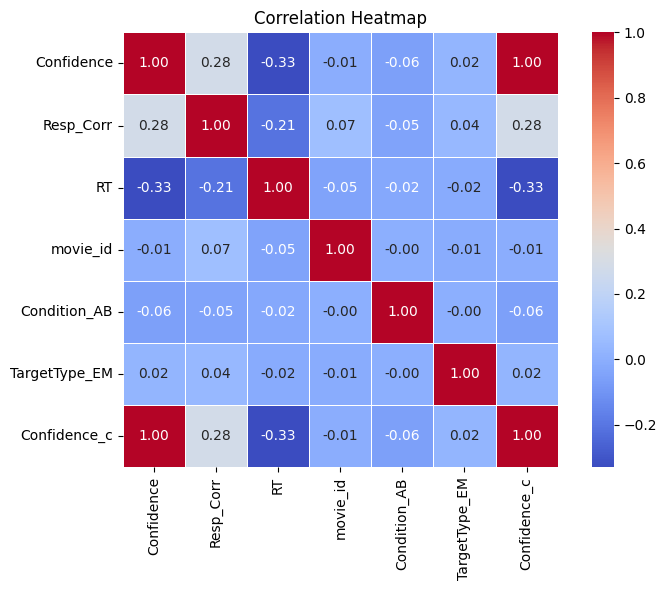

In [6]:
plot_correlation_heatmap(df)

In [8]:
import numpy as np
import pandas as pd

def logistic_regression_report(result):
    """
    Generate a full report for logistic regression:
    - Coefficients
    - Odds ratios
    - 95% CI
    - p-values
    - Text interpretation
    """

    print("\n" + "="*80)
    print("LOGISTIC REGRESSION REPORT")
    print("="*80)

    # Extract values
    params   = result.params
    conf_int = result.conf_int()
    pvals    = result.pvalues

    # Build table
    report_df = pd.DataFrame({
        'Coefficient (β)': params,
        'Odds Ratio (expβ)': np.exp(params),
        'CI Lower (2.5%)': np.exp(conf_int[0]),
        'CI Upper (97.5%)': np.exp(conf_int[1]),
        'p-value': pvals
    })

    # Significance stars
    def stars(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else: return ''

    report_df['Significance'] = report_df['p-value'].apply(stars)

    print("\n📊 Model Summary Table:\n")
    print(report_df.to_string(float_format="{:.4f}".format))

    # ── Interpretation ───────────────────────────────────────────────
    print("\n" + "-"*80)
    print("INTERPRETATION")
    print("-"*80)

    for var in report_df.index:
        if var == 'Intercept':
            continue

        beta = report_df.loc[var, 'Coefficient (β)']
        or_val = report_df.loc[var, 'Odds Ratio (expβ)']
        p = report_df.loc[var, 'p-value']

        if p < 0.05:
            direction = "increases" if beta > 0 else "decreases"

            print(f"\n• {var} is a SIGNIFICANT predictor (p = {p:.4f}).")

            print(f"  → A one-unit increase in {var} {direction} the odds of correct response by "
                  f"{or_val:.2f} times.")

            if beta > 0:
                print(f"  → This means higher {var} is associated with HIGHER probability of correct recognition.")
            else:
                print(f"  → This means higher {var} is associated with LOWER probability of correct recognition.")
        else:
            print(f"\n• {var} is NOT a significant predictor (p = {p:.4f}).")

    # ── Most important predictors ────────────────────────────────────
    print("\n" + "-"*80)
    print("KEY TAKEAWAYS")
    print("-"*80)

    sig_vars = report_df[report_df['p-value'] < 0.05].copy()

    if not sig_vars.empty:
        sig_vars = sig_vars.sort_values(by='p-value')

        print("\nMost significant predictors (in order):")
        for var in sig_vars.index:
            if var == 'Intercept':
                continue
            print(f"  - {var} (p = {sig_vars.loc[var, 'p-value']:.4f})")
    else:
        print("No statistically significant predictors found.")

    print("\n" + "="*80)

    return report_df

In [9]:
# 3. Run logistic regression -----------------------------------------------
result = run_logistic_regression(df)

report = logistic_regression_report(result)


LOGISTIC REGRESSION (GLM - Binomial)
                 Generalized Linear Model Regression Results                  
Dep. Variable:              Resp_Corr   No. Observations:                 6640
Model:                            GLM   Df Residuals:                     6635
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2511.8
Date:                Tue, 21 Apr 2026   Deviance:                       5023.7
Time:                        23:21:20   Pearson chi2:                 6.54e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06941
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [ ]:

# 4. Odds Ratios -----------------------------------------------------------
or_table = print_odds_ratios(result)


------------------------------------------------------------
ODDS RATIOS  (exp(β))  with 95% Confidence Intervals
------------------------------------------------------------
                              OR  OR_2.5%  OR_97.5%  p-value Significant
Intercept                 7.0667   6.2070    8.0453   0.0000         ***
Condition_AB              0.7883   0.6753    0.9202   0.0026          **
TargetType_EM             1.2336   1.0691    1.4235   0.0040          **
Confidence_c              1.8934   1.7483    2.0505   0.0000         ***
Condition_AB:Confidence_c 0.9111   0.8170    1.0161   0.0943            



AUC-ROC : 0.7103

Classification Report (threshold = 0.5):
               precision    recall  f1-score   support

Incorrect (0)       0.47      0.03      0.05       964
  Correct (1)       0.86      1.00      0.92      5676

     accuracy                           0.85      6640
    macro avg       0.66      0.51      0.49      6640
 weighted avg       0.80      0.85      0.79      6640

McFadden's Pseudo-R² : 0.0868


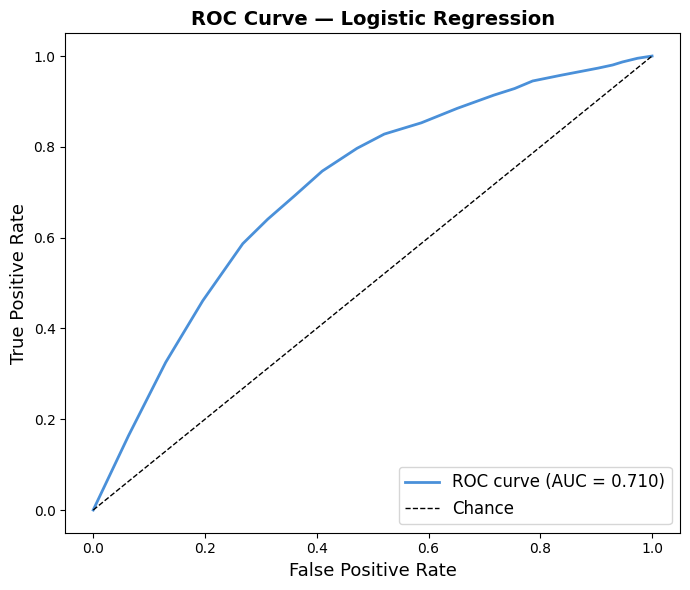

  → Saved: roc_curve.png


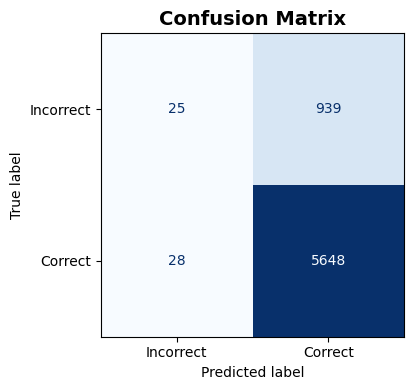

  → Saved: confusion_matrix.png


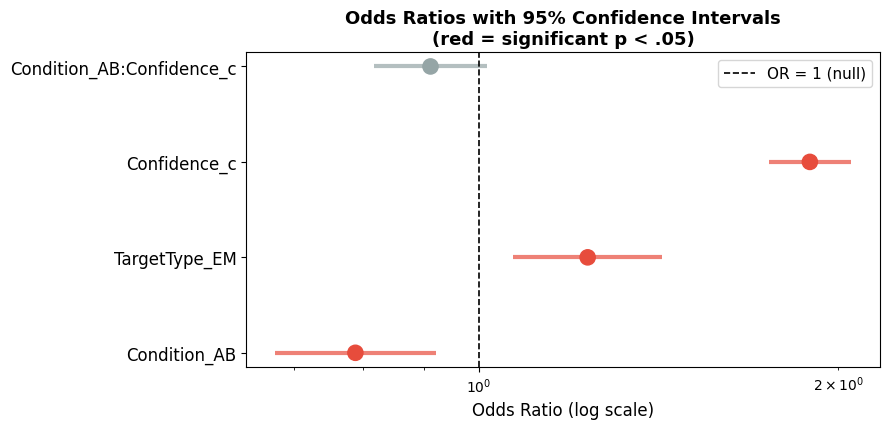

  → Saved: odds_ratio_forest.png


In [7]:
# 5. Model evaluation ------------------------------------------------------
df, auc, pseudo_r2 = evaluate_model(df, result, or_table)


Generating effect visualisations …


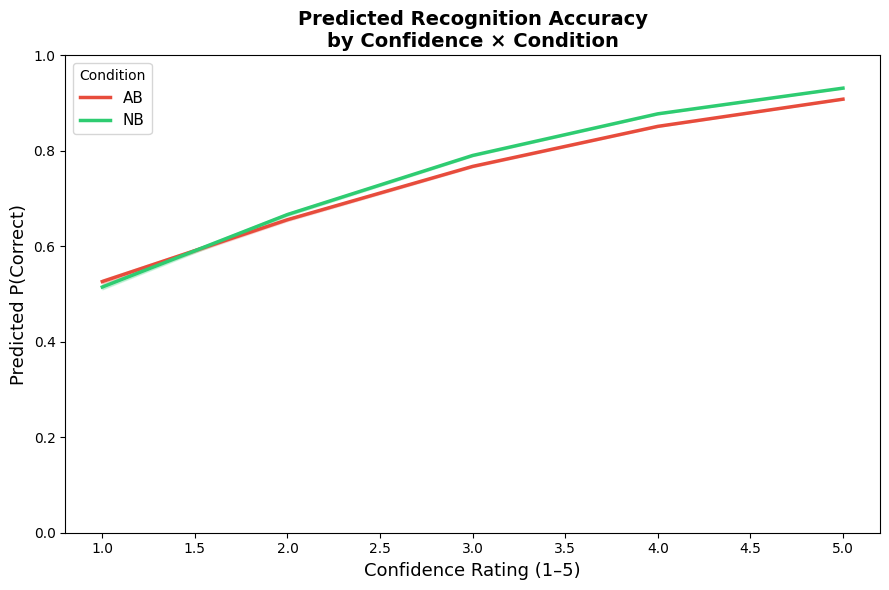

  → Saved: predicted_prob_conf_x_condition.png


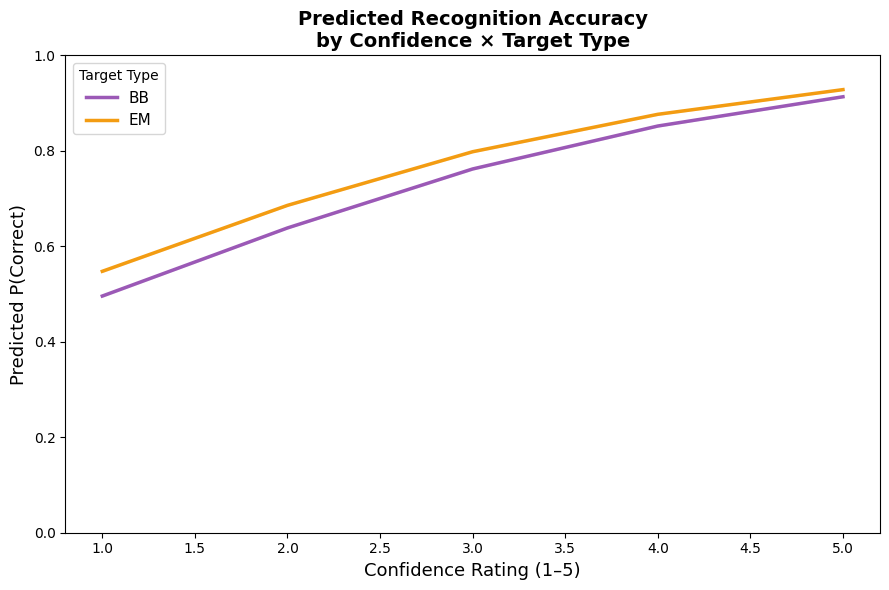

  → Saved: predicted_prob_conf_x_targettype.png


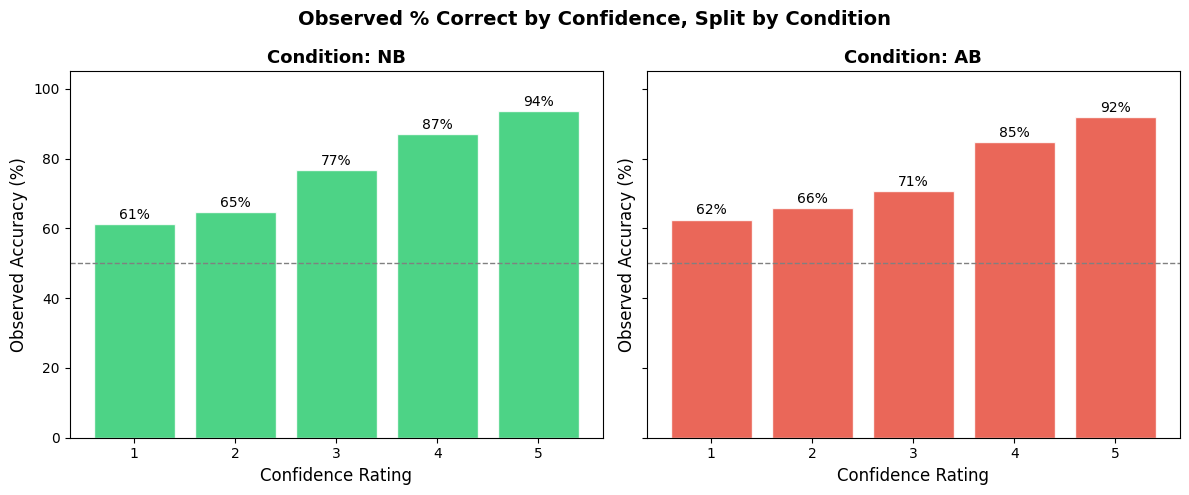

  → Saved: accuracy_by_confidence_condition.png


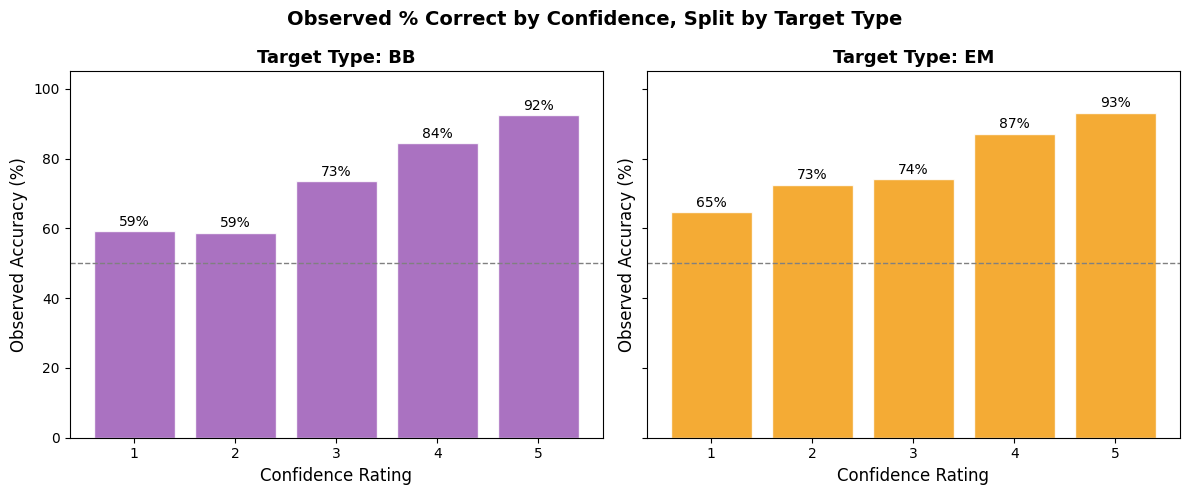

  → Saved: accuracy_by_confidence_targettype.png


In [8]:
# 6. Effect visualisations -------------------------------------------------
print("\nGenerating effect visualisations …")
plot_effects(df)